Loading data set

In [4]:
import pandas as pd
data= pd.read_csv("Mall_Customers.csv")

Checking first 5 rows of the dataset

In [5]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Checking the last 5 rows of the dataset

In [6]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [56]:
# --- STEP 3: DATA PREPROCESSING ---
print("--- Missing Values Check ---")
print(data.isnull().sum())  # Verifies if any cells are empty

print("\n--- Duplicate Records Check ---")
print(f"Total Duplicate Rows: {data.duplicated().sum()}")  # Verifies if data has duplicates

# Feature Extraction: Separating features for the model
# Selecting Annual Income and Spending Score for visual clustering
X = data.iloc[:, [3, 4]].values 

# Optional Feature Scaling (Highly recommended for K-Means)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

--- Missing Values Check ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Duplicate Records Check ---
Total Duplicate Rows: 0


Finding the shape of the dataset

In [7]:
data.shape

(200, 5)

In [8]:
print("Number of Rows : ", data.shape[0])
print("Number of Columns : ", data.shape[1])

Number of Rows :  200
Number of Columns :  5


Imformation of dataset, total number of rows

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


Checking NULL

In [12]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Get overall statistic of dataset

In [13]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


K-Means Clustering Methods

In [14]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [15]:
X=data[['Annual Income (k$)','Spending Score (1-100)']]

In [16]:
from sklearn.cluster import KMeans

In [21]:
k_means= KMeans()
# Only trains the model
k_means.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 2)",

In [23]:
k_means= KMeans()
# train and create dependent variables too
k_means.fit_predict(X)

array([1, 3, 5, 3, 1, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 1, 3, 1, 3, 1, 3,
       5, 3, 5, 3, 1, 3, 1, 3, 5, 3, 5, 3, 5, 3, 5, 3, 1, 3, 1, 3, 1, 4,
       1, 4, 4, 4, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 7, 4, 4, 7, 7, 4, 4, 4, 4,
       4, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 7, 0, 7, 0, 2, 0, 2, 0,
       7, 0, 2, 0, 2, 0, 2, 0, 2, 0, 7, 0, 2, 0, 7, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 7, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 6, 2, 0, 2, 6, 2, 6, 2, 6, 6, 6,
       6, 6], dtype=int32)

To find optimal number of clusters we are going to use elbow method

In [32]:
wcss=[]
for i in range(1,11):
    k_means= KMeans(n_clusters=i)
    k_means.fit(X)
    wcss.append(k_means.inertia_)

In [33]:
wcss

[269981.28,
 184131.88502788506,
 106348.37306211122,
 73880.64496247195,
 44448.4554479337,
 37558.92202302528,
 32227.558007109168,
 25028.020475269415,
 23867.91002886004,
 22394.68543461438]

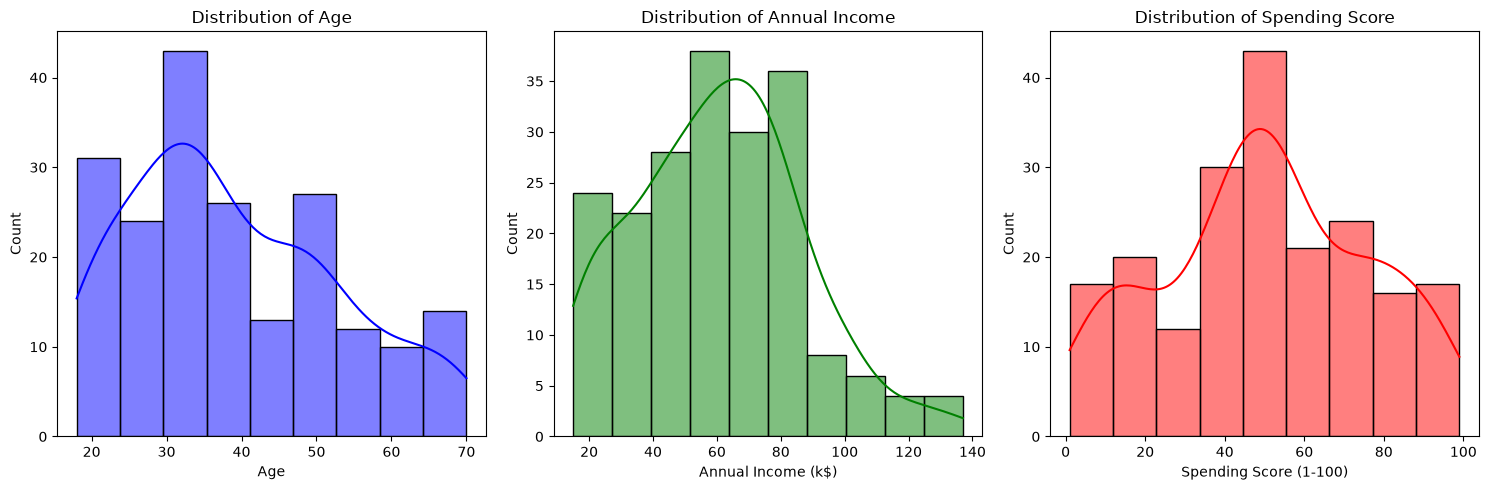

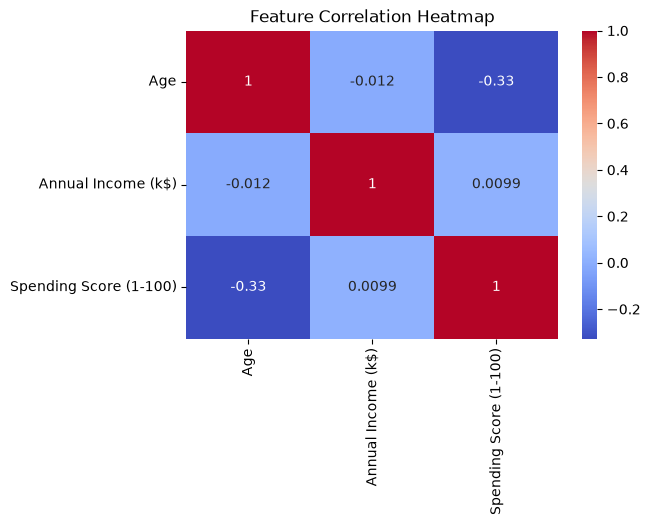

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 4: EXPLORATORY DATA ANALYSIS (EDA) ---
plt.figure(figsize=(15, 5))

# 1. Distribution of Age
plt.subplot(1, 3, 1)
sns.histplot(data['Age'], kde=True, color='blue')
plt.title('Distribution of Age')

# 2. Distribution of Annual Income
plt.subplot(1, 3, 2)
sns.histplot(data['Annual Income (k$)'], kde=True, color='green')
plt.title('Distribution of Annual Income')

# 3. Distribution of Spending Score
plt.subplot(1, 3, 3)
sns.histplot(data['Spending Score (1-100)'], kde=True, color='red')
plt.title('Distribution of Spending Score')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap to check feature relationships
plt.figure(figsize=(6, 4))
sns.heatmap(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [34]:
import matplotlib.pyplot as plt

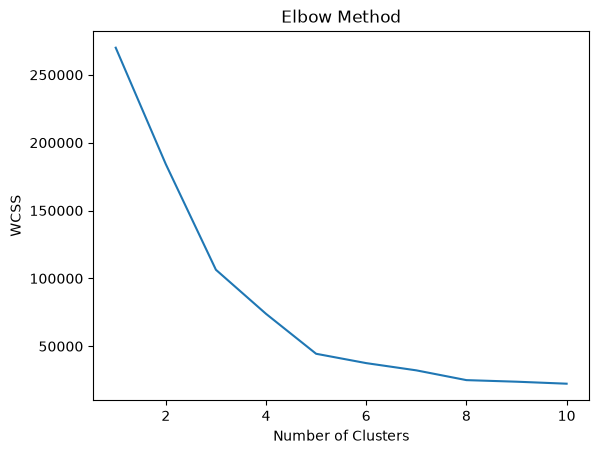

In [35]:
plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


Using optimal number of clusters here

In [30]:
X=data[['Annual Income (k$)','Spending Score (1-100)']]

In [36]:
k_means=KMeans(n_clusters=5,random_state=42)
y_means=k_means.fit_predict(X)

In [37]:
y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [58]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score to evaluate clustering quality
score = silhouette_score(X, k_means.labels_)
print(f"The Silhouette Score for K=5 clusters is: {score:.4f}")
print("Interpretation: A score closer to 1 implies distinct, well-separated clusters.")

The Silhouette Score for K=5 clusters is: 0.5539
Interpretation: A score closer to 1 implies distinct, well-separated clusters.


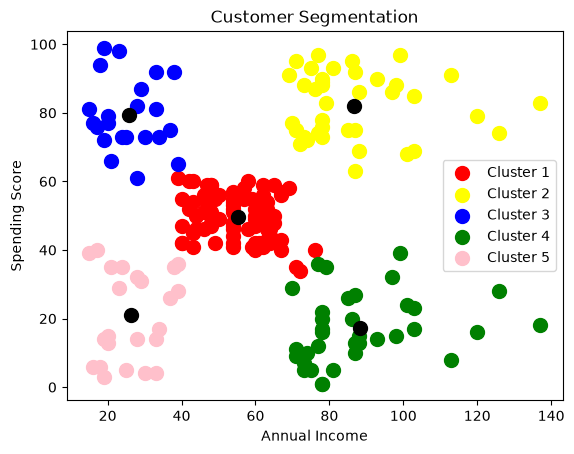

In [44]:
plt.scatter(X.iloc[y_means==0,0], X.iloc[y_means==0,1],s=100, c='red', label="Cluster 1")
plt.scatter(X.iloc[y_means==1,0], X.iloc[y_means==1,1],s=100, c='yellow', label="Cluster 2")
plt.scatter(X.iloc[y_means==2,0], X.iloc[y_means==2,1],s=100, c='blue', label="Cluster 3")
plt.scatter(X.iloc[y_means==3,0], X.iloc[y_means==3,1],s=100, c='green', label="Cluster 4")
plt.scatter(X.iloc[y_means==4,0], X.iloc[y_means==4,1],s=100, c='pink', label="Cluster 5")
plt.scatter(k_means.cluster_centers_[:,0],k_means.cluster_centers_[:,1],s=100, c="black")
plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [51]:
k_means.predict([[20,85]])

d:\PYTHON\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [52]:
import joblib as jb

In [53]:
jb.dump(k_means, "Customer_segmentation")

['Customer_segmentation']

Checking the model work efficiency

In [54]:
model= jb.load('Customer_segmentation')

In [55]:
model.predict([[20,85]])

d:\PYTHON\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)